In [1]:
import pandas as pd

# Đọc file CSV
file_path = "your_file.csv"
df = pd.read_csv("D:\KL-lieuvth2\df_woe_long_list.csv")

# Kiểm tra tổng số null/NaN của từng cột
null_check = df.isna().sum()

# Chỉ hiển thị các cột có null/NaN
null_check = null_check[null_check > 0]

print("Các cột có NULL/NaN:")
print(null_check)

# Tổng số giá trị NULL/NaN toàn DataFrame
print("\nTổng số NULL/NaN:", df.isna().sum().sum())

<>:5: SyntaxWarning: invalid escape sequence '\K'
<>:5: SyntaxWarning: invalid escape sequence '\K'
C:\Users\CPN\AppData\Local\Temp\ipykernel_12800\1817391744.py:5: SyntaxWarning: invalid escape sequence '\K'
  df = pd.read_csv("D:\KL-lieuvth2\df_woe_long_list.csv")


Các cột có NULL/NaN:
Series([], dtype: int64)

Tổng số NULL/NaN: 0


In [1]:
import pandas as pd

OUTPUT_PATH = "binning_tables.xlsx"

import pickle

# Load binners
with open("binning_tables.pkl", "rb") as f:
    binning_tables = pickle.load(f)

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:

    start_row = 0

    for feature, bt in binning_tables.items():

        # Tên feature
        pd.DataFrame([[feature]]).to_excel(
            writer,
            sheet_name="Binning_Tables",
            startrow=start_row,
            index=False,
            header=False
        )

        start_row += 1

        # Binning table
        bt.to_excel(
            writer,
            sheet_name="Binning_Tables",
            startrow=start_row,
            index=True
        )

        # Cách một dòng trước feature tiếp theo
        start_row += len(bt) + 3

print(f"Saved to: {OUTPUT_PATH}")

Saved to: binning_tables.xlsx


In [16]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import textwrap
import os
import pickle

with open("binners.pkl", "rb") as f:
    binners = pickle.load(f)

PLOT_DIR = "binning_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

plt.close("all")

for feature, ob in binners.items():

    safe_feature = "".join(
        c if c.isalnum() or c in "_-" else "_"
        for c in str(feature)
    )
    output_path = os.path.join(PLOT_DIR, f"{safe_feature}.png")

    plt.close("all")

    ob.binning_table.plot(
        metric="event_rate",
        show_bin_labels=True,
        figsize=(18, 10)
    )

    fig = plt.gcf()

    # ── Wrap x-axis labels ──────────────────────────────────
    for ax in fig.axes:
        labels = ax.get_xticklabels()
        for label in labels:
            text = label.get_text()
            if len(text) > 20:
                wrapped = "\n".join(
                    textwrap.wrap(text, width=20,
                                  break_long_words=False,
                                  break_on_hyphens=False)
                )
                label.set_text(wrapped)
        ax.set_xticklabels(labels)
        ax.tick_params(axis="x", pad=5)

    # ── Fix legend: lấy từ ax[1], đặt vào figure ───────────
    for ax in fig.axes:
        leg = ax.get_legend()
        if leg is not None:
            handles    = leg.legend_handles
            leg_labels = [t.get_text() for t in leg.get_texts()]
            leg.remove()
            fig.legend(
                handles, leg_labels,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.0),
                ncol=4,
                frameon=True,
                fontsize=10,
            )
            break

    # ── Tính bottom động theo chiều cao label thực tế ───────
    fig.canvas.draw()   # render trước để đo được kích thước

    max_label_height = 0
    for ax in fig.axes:
        for label in ax.get_xticklabels():
            bb = label.get_window_extent()
            if bb.height > 0:
                h_frac = bb.height / fig.get_size_inches()[1] / fig.dpi
                max_label_height = max(max_label_height, h_frac)

    legend_space = 0.07   # chỗ cho legend
    xlabel_space = 0.04   # chỗ cho tiêu đề "Bin"
    padding      = 0.02
    bottom = legend_space + xlabel_space + max_label_height + padding
    bottom = max(bottom, 0.15)   # tối thiểu
    bottom = min(bottom, 0.35)   # tối đa

    fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=bottom)

    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

print(f"Đã lưu {len(binners)} plots vào thư mục: {os.path.abspath(PLOT_DIR)}")

c:\Users\CPN\AppData\Local\Programs\Python\Python312\Lib\site-packages\optbinning\binning\binning_statistics.py:865: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
c:\Users\CPN\AppData\Local\Programs\Python\Python312\Lib\site-packages\optbinning\binning\binning_statistics.py:865: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
c:\Users\CPN\AppData\Local\Programs\Python\Python312\Lib\site-packages\optbinning\binning\binning_statistics.py:865: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
c:\Users\CPN\AppData\Local\Programs\Python\Python312\Lib\site-packages\optbinning\binning\binning_statistics.py:865: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
c:\Users\CPN\AppData\Local\Programs\Python\Python312\Lib\site-packages\optbinning\binning\binning_statistics.py:865: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be

Đã lưu 176 plots vào thư mục: d:\KL-lieuvth2\binning_plots


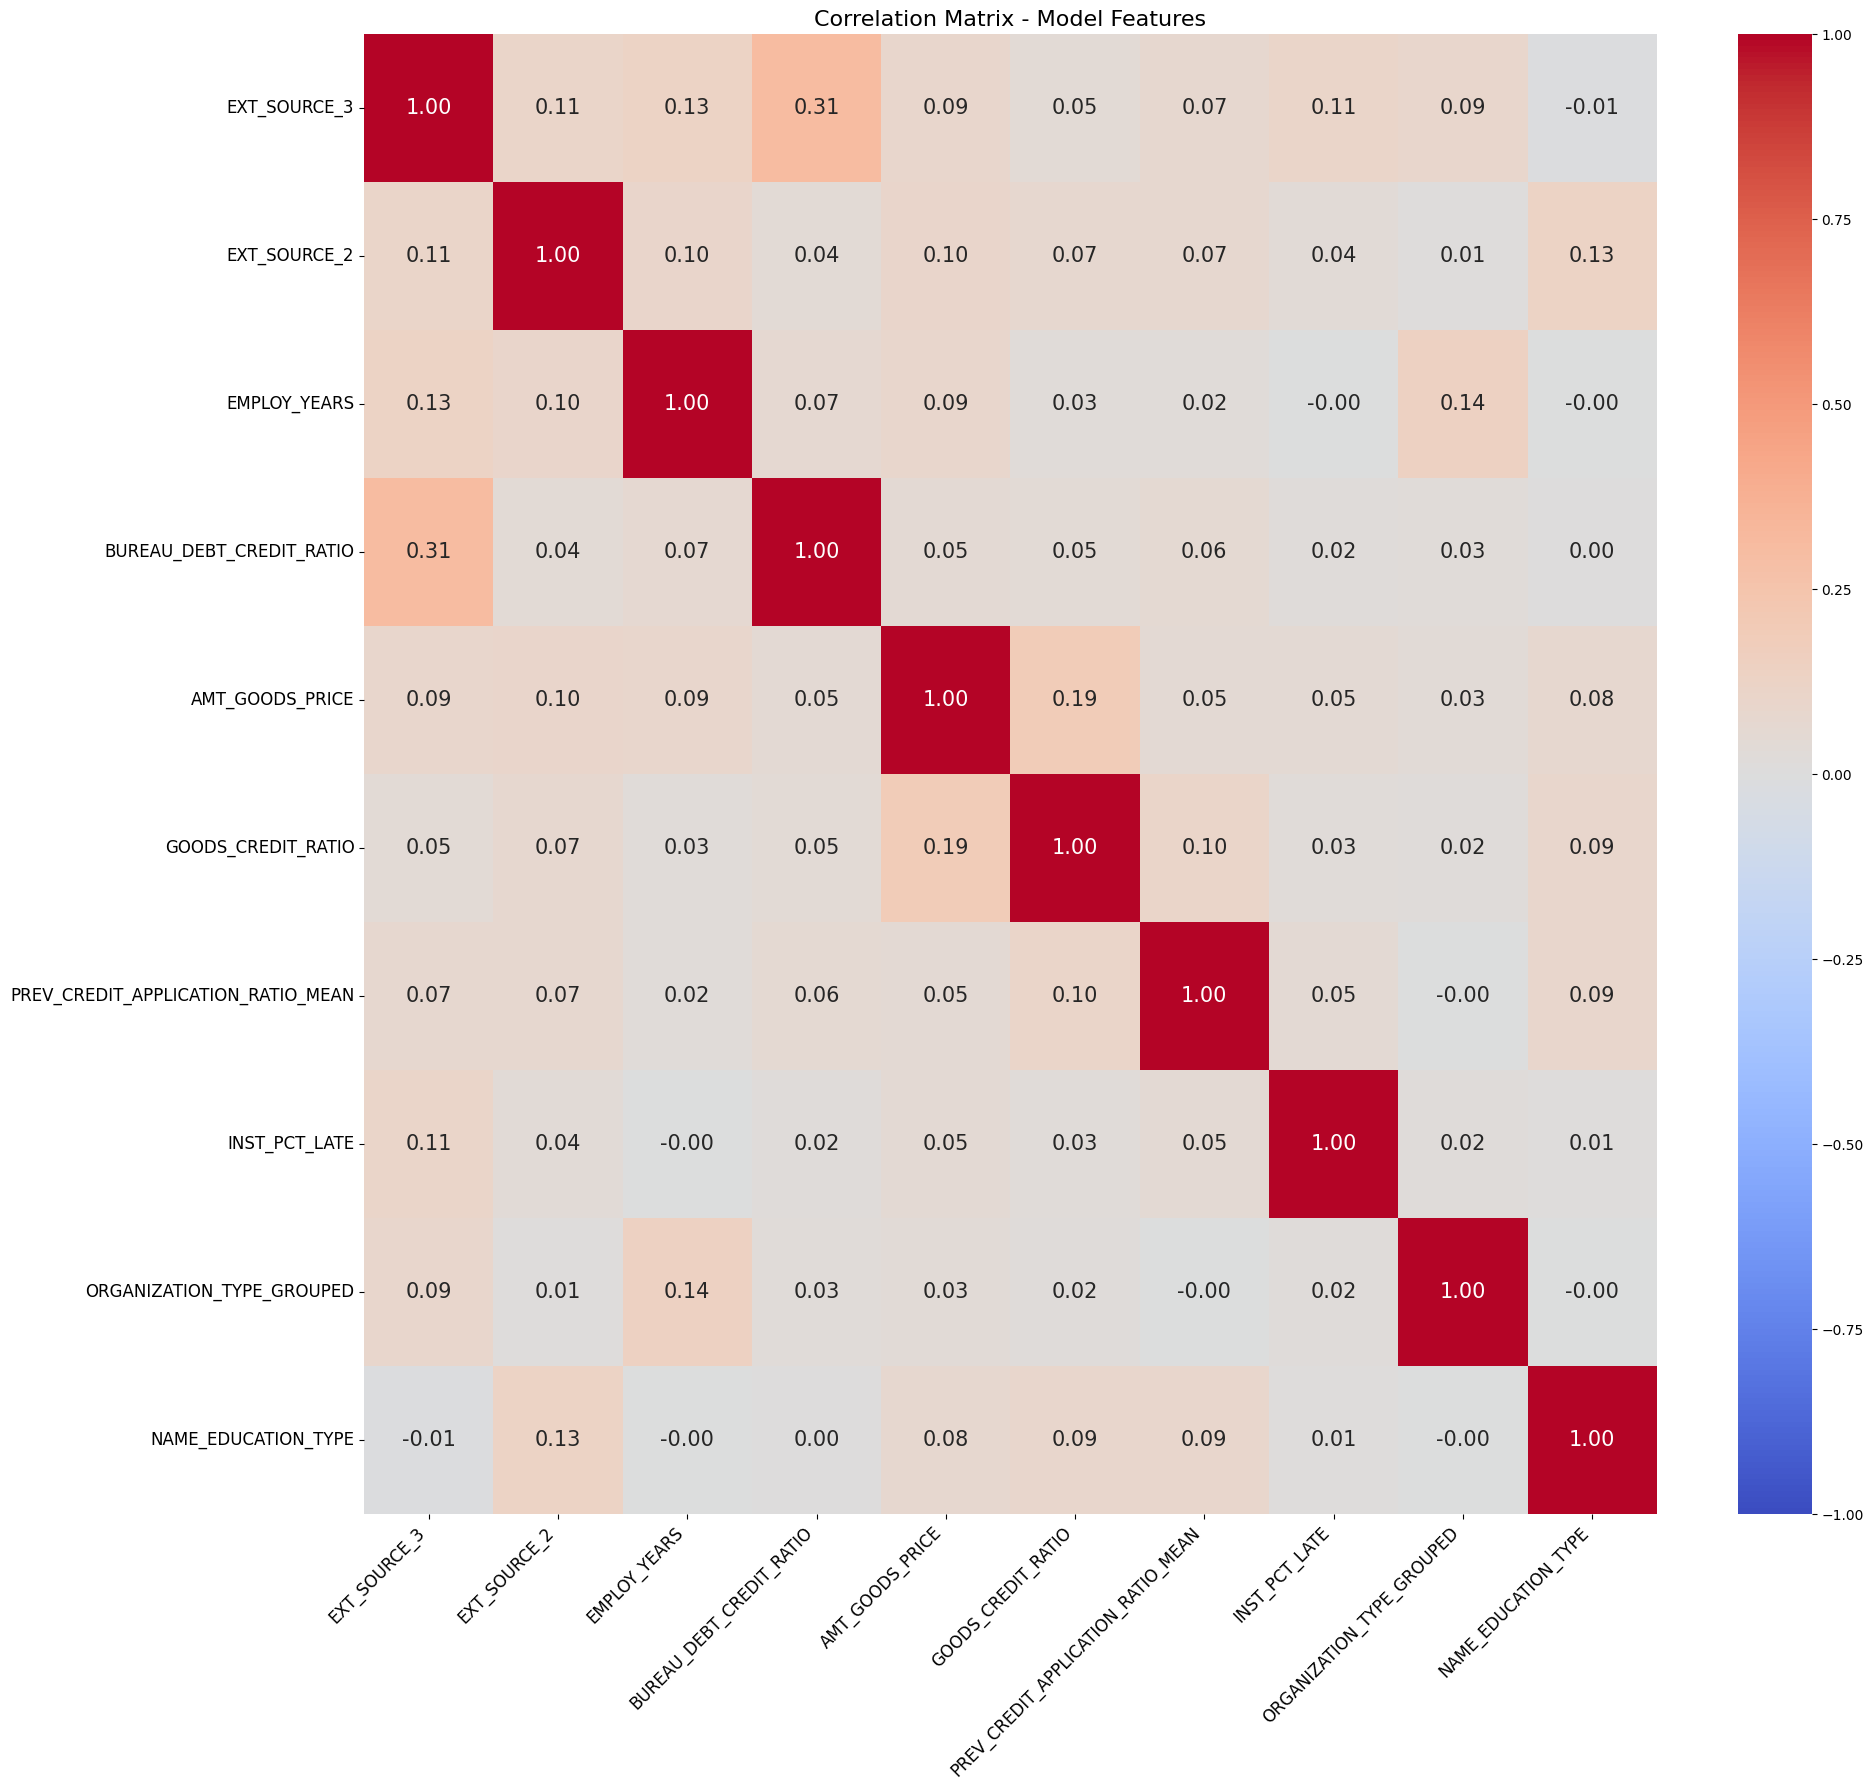

In [10]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CORR_PATH  = r"D:\KL-lieuvth2\correlation_matrix.csv"
MODEL_PATH = r"D:\KL-lieuvth2\model.pkl"

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

features = [x for x in model.params.index if x != "const"]

corr = pd.read_csv(CORR_PATH, index_col=0)
features = [x for x in features if x in corr.index]
corr = corr.loc[features, features]

plt.figure(figsize=(20, 18))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 15}
)

plt.xticks(fontsize=12, rotation=45, ha="right")
plt.yticks(fontsize=12, rotation=0)

plt.title("Correlation Matrix - Model Features", fontsize=16)
plt.tight_layout()
plt.show()